# 02 - Exploratory Data Analysis

**Phase 4.** Four sections, following the project guide: customer
demographics, buyer intent, property behaviour, and buyer-investment
relationships. The last of these produces the most consequential finding in
the whole project.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

from src import config as cfg, visuals as vz
from src.data_cleaning import load_and_clean
from src.feature_engineering import build_client_features
vz.apply_style()

clients, properties, _ = load_and_clean(save=False)
features = build_client_features(clients, properties, save=False)
print(features.shape)


(2000, 39)


## A. Customer demographics

findfont: Failed to find font weight 600, now using 700.


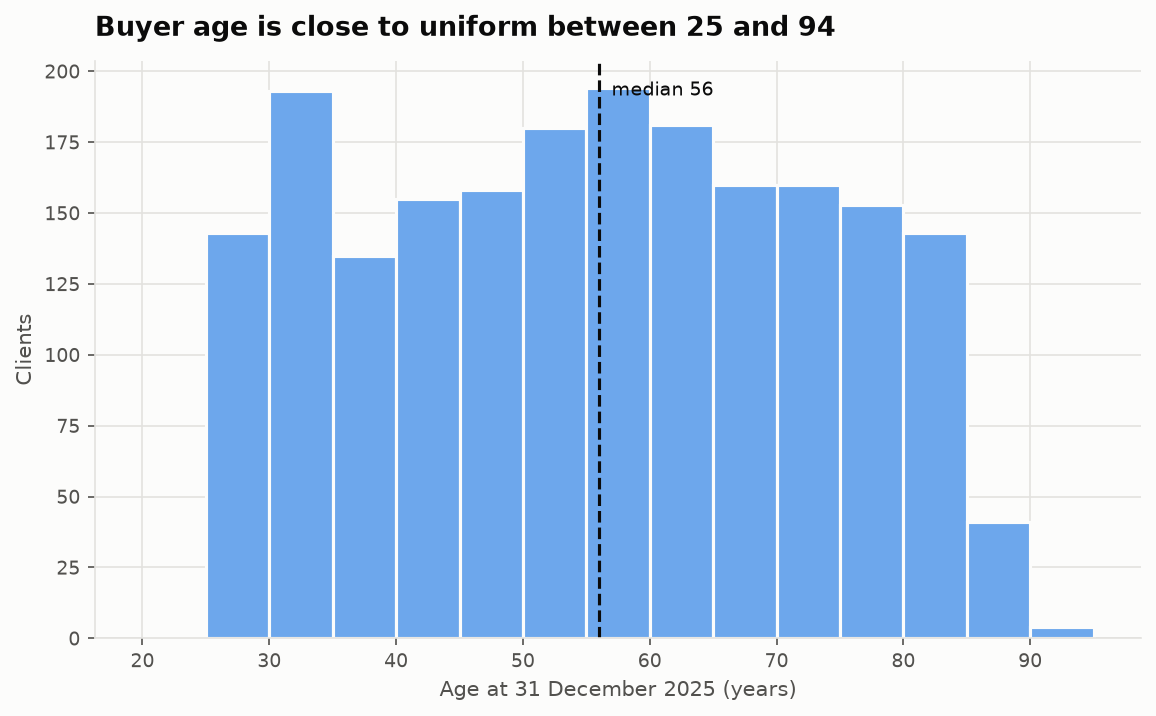

findfont: Failed to find font weight 600, now using 700.


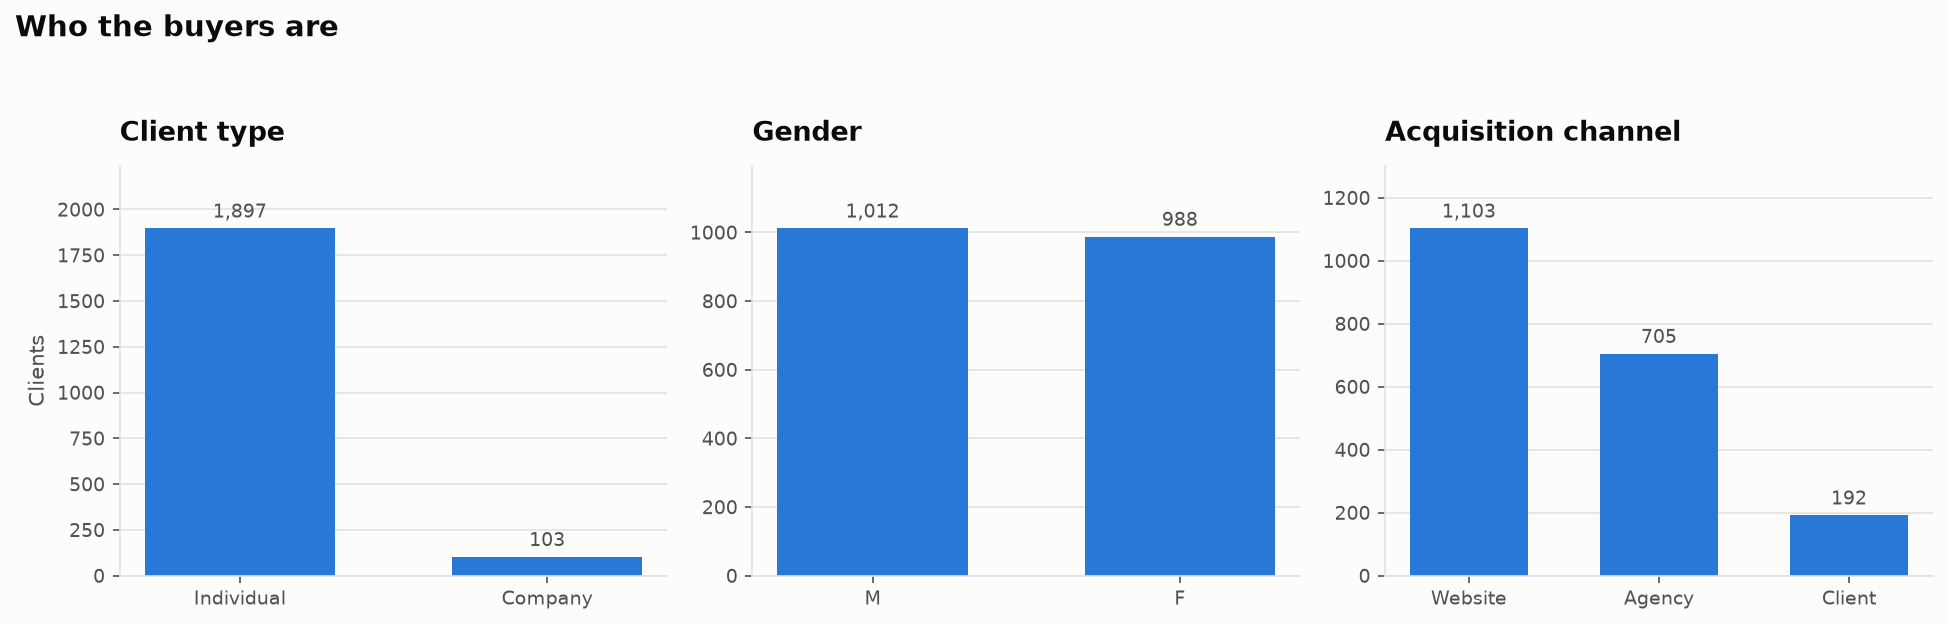

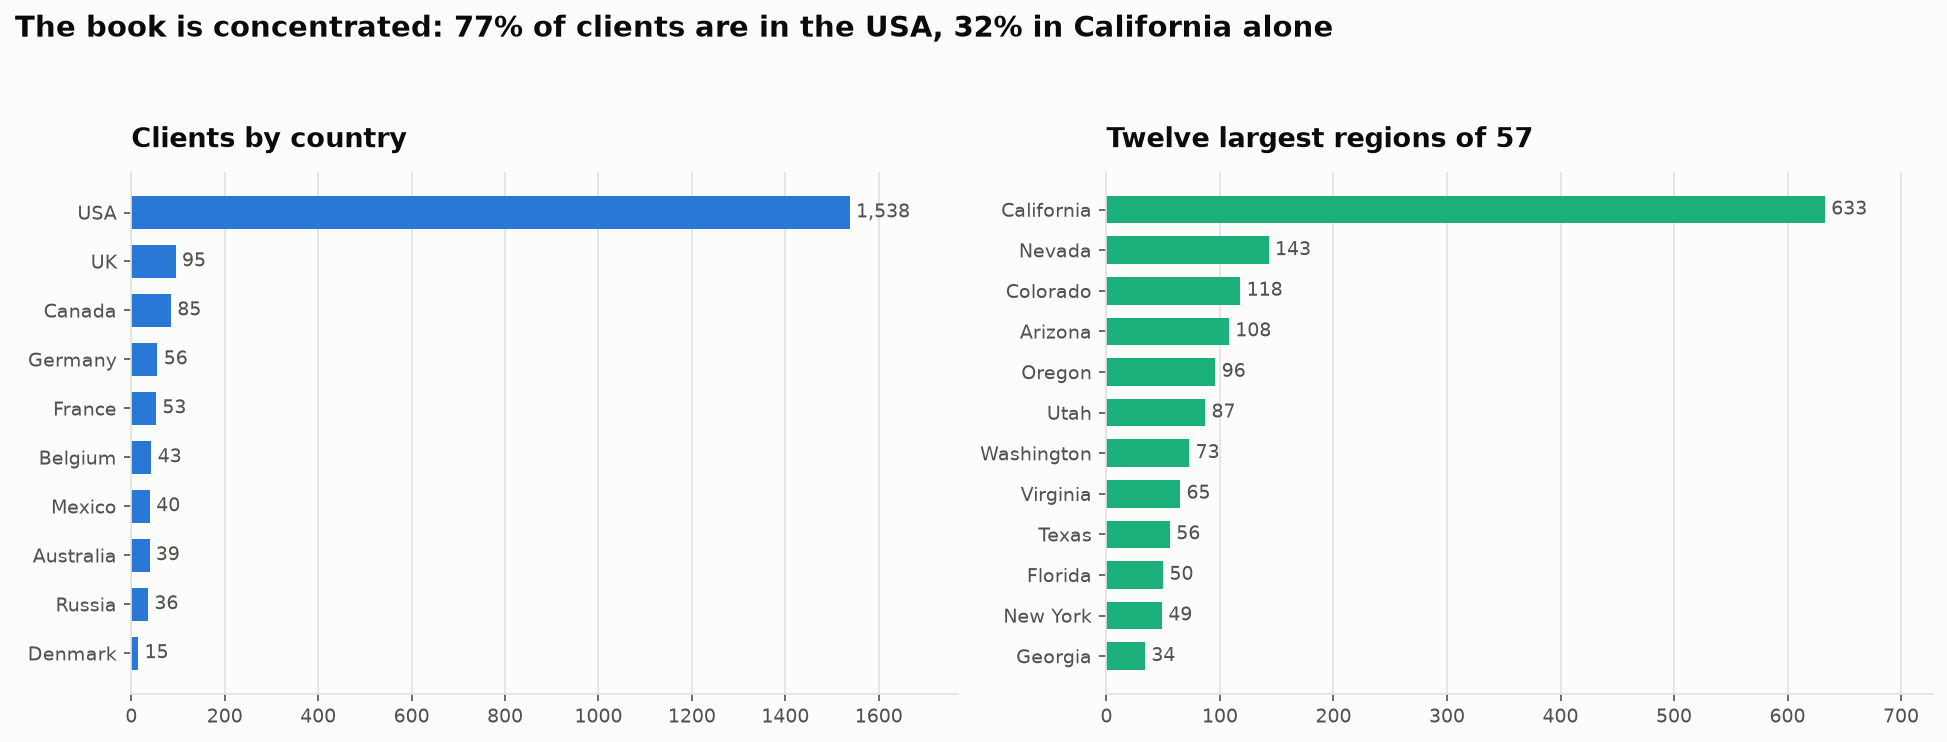

In [2]:
from IPython.display import Image, display
display(Image(str(vz.fig_age_distribution(features))))
display(Image(str(vz.fig_demographic_mix(features))))
display(Image(str(vz.fig_geography(features))))


## B. Buyer intent

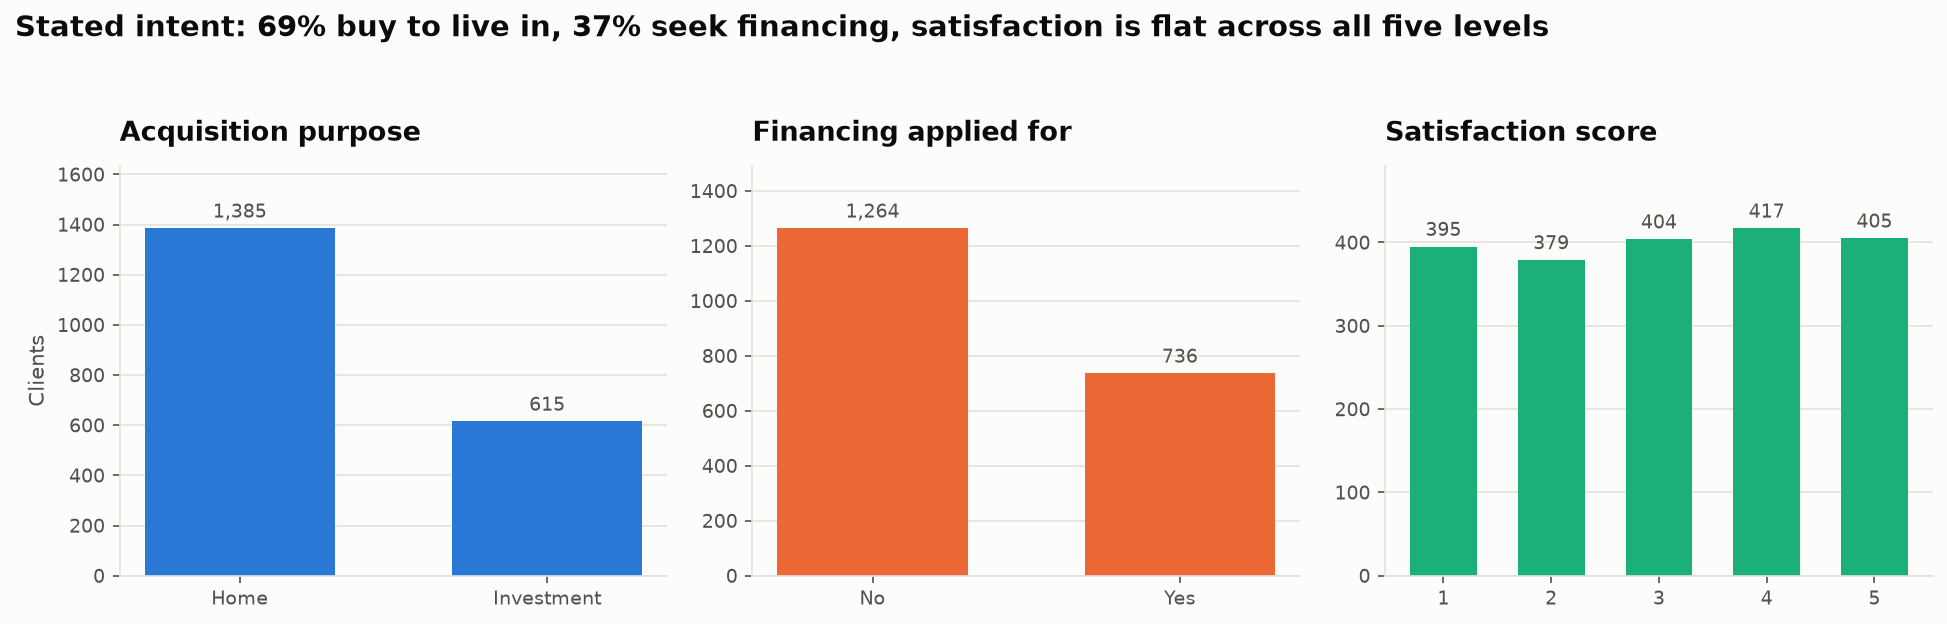

acquisition_purpose
Home          1385
Investment     615

loan_applied
No     1264
Yes     736


In [3]:
display(Image(str(vz.fig_buyer_intent(features))))
print(features['acquisition_purpose'].value_counts().to_string())
print()
print(features['loan_applied'].value_counts().to_string())


## C. Property behaviour

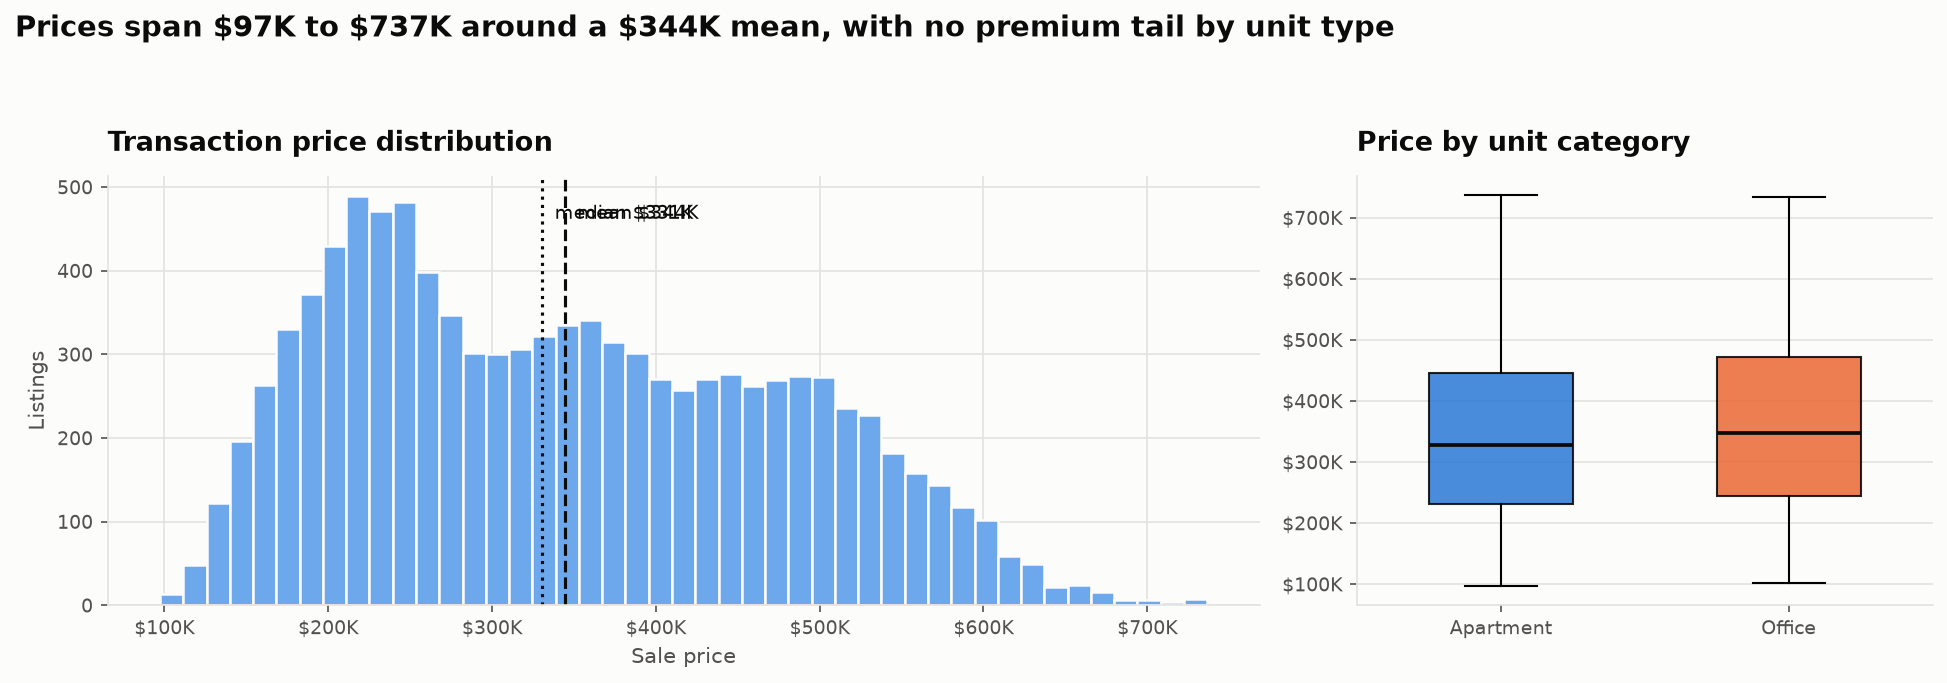

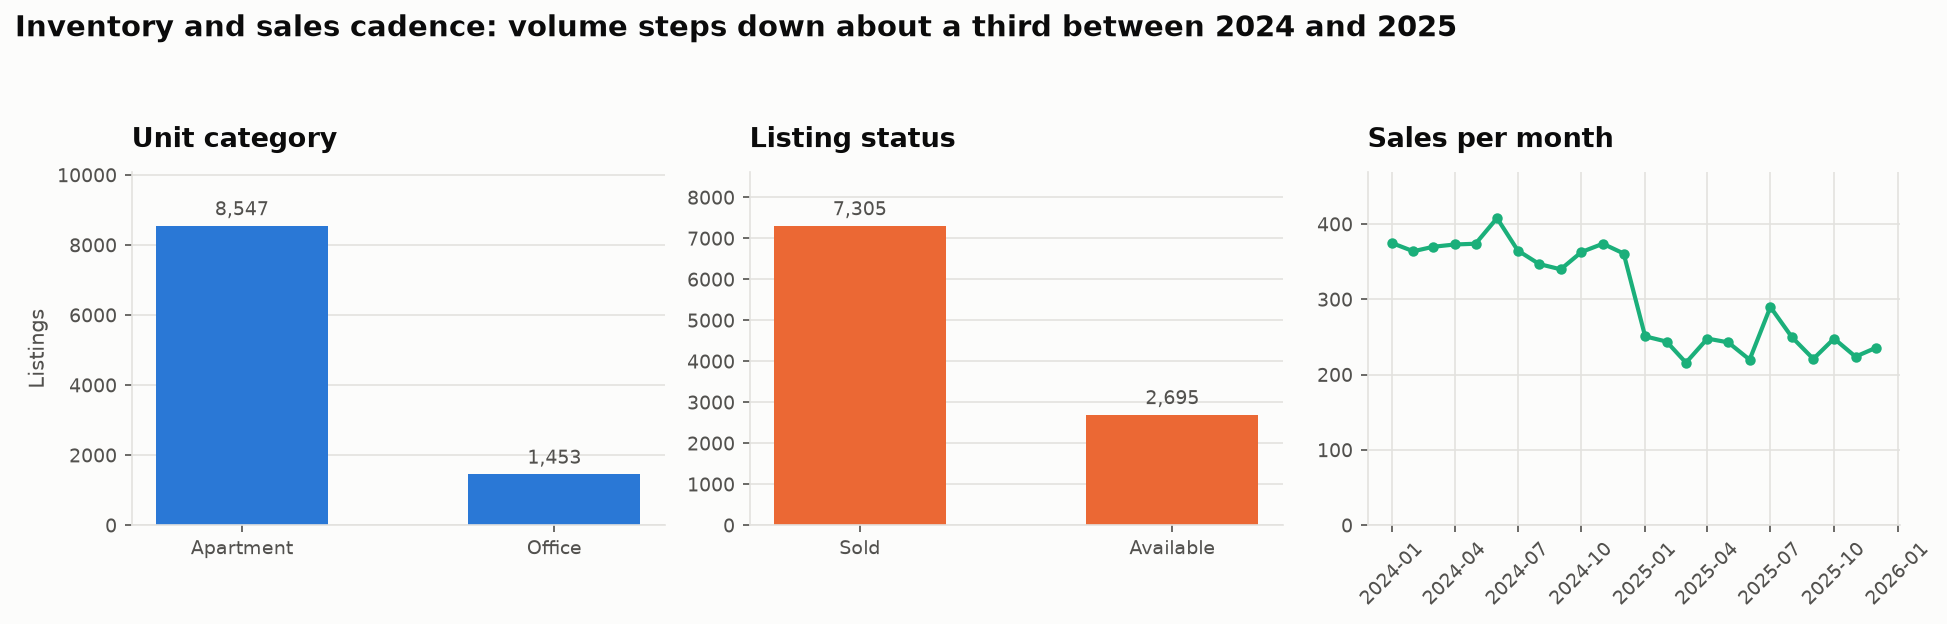

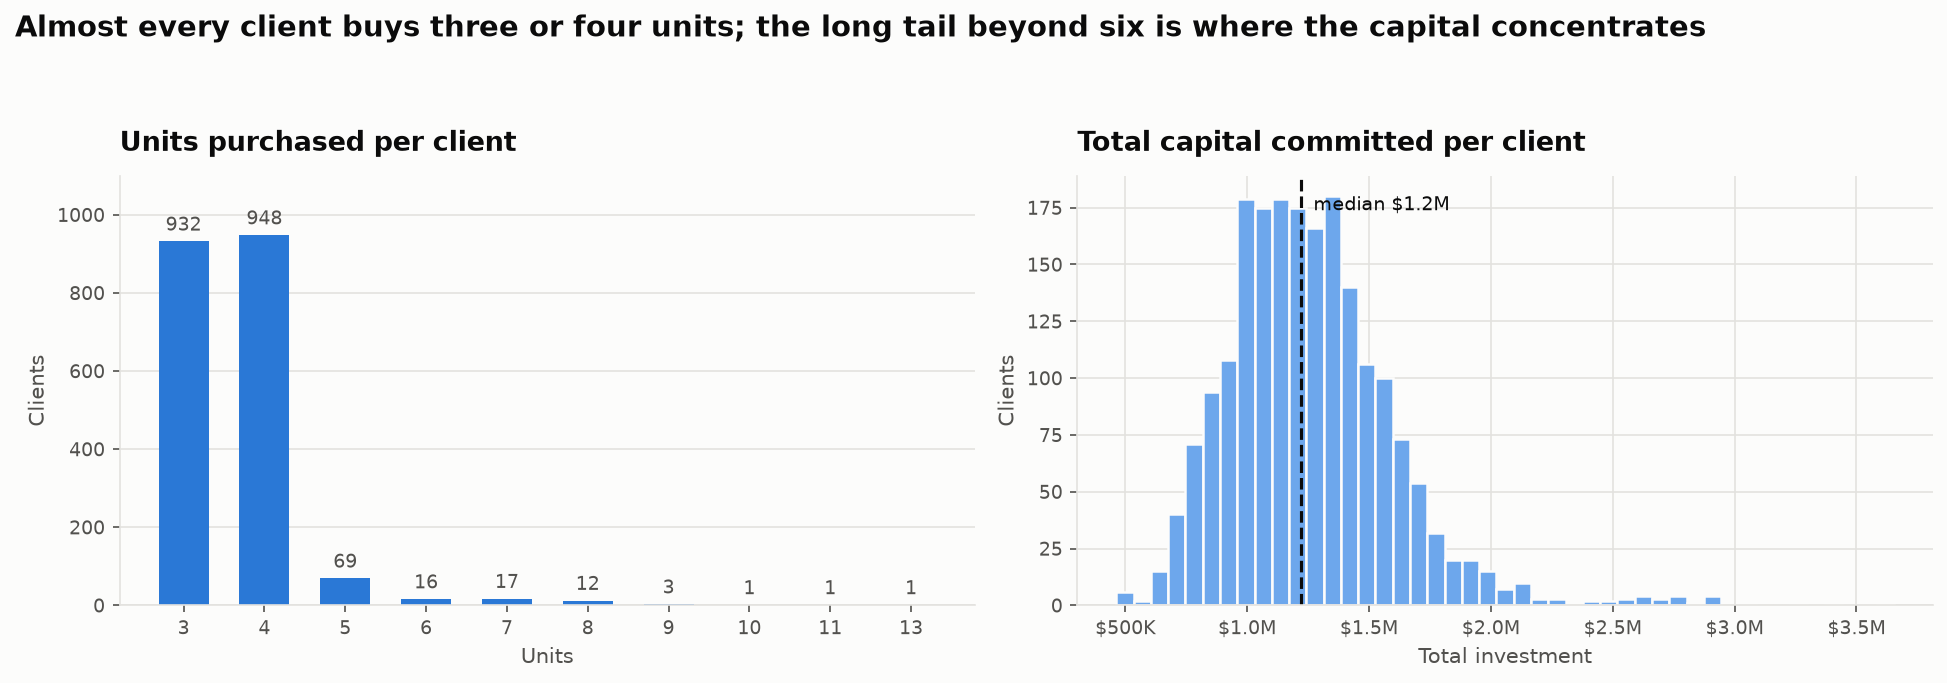

count          10000.0
mean     344374.678683
std      131563.099417
min            97402.8
25%        232173.6425
50%         330680.845
75%         448852.575
max          736652.27


In [4]:
display(Image(str(vz.fig_price_distribution(properties))))
display(Image(str(vz.fig_inventory(properties))))
display(Image(str(vz.fig_portfolio_size(features))))
print(properties['sale_price'].describe().to_string())


## D. Buyer-investment relationships - the key finding

The project guide expects relationships between declared attributes and
spending. We test them formally rather than assuming them.


In [5]:
from scipy import stats
for cat in ['client_type', 'acquisition_purpose', 'loan_applied']:
    groups = [g['total_investment'].to_numpy()
              for _, g in features.groupby(cat, observed=True)]
    t, p = stats.ttest_ind(*groups, equal_var=False)
    n1, n2 = len(groups[0]), len(groups[1])
    pooled = np.sqrt(((n1-1)*groups[0].var(ddof=1) + (n2-1)*groups[1].var(ddof=1)) / (n1+n2-2))
    d = (groups[0].mean() - groups[1].mean()) / pooled
    print(f"{cat:22s} vs total_investment: p={p:.4f}  Cohen's d={d:+.3f}")

print()
print(f"age          vs total_investment: r={features['age'].corr(features['total_investment']):+.4f}")
print(f"satisfaction vs total_investment: r={features['satisfaction_score'].corr(features['total_investment']):+.4f}")


client_type            vs total_investment: p=0.9275  Cohen's d=+0.010
acquisition_purpose    vs total_investment: p=0.5527  Cohen's d=+0.030
loan_applied           vs total_investment: p=0.9363  Cohen's d=+0.004

age          vs total_investment: r=+0.0572
satisfaction vs total_investment: r=+0.0489


**Every declared attribute is statistically independent of spending.**
All p-values are far above 0.05 and every effect size is below |d| = 0.07.

This is not a defect in the analysis - it is the central constraint on the
whole project. Segmentation cannot be built on what buyers *declare*; it has
to be built on what they *transact*. That decision drives every modelling
choice in notebook 04.


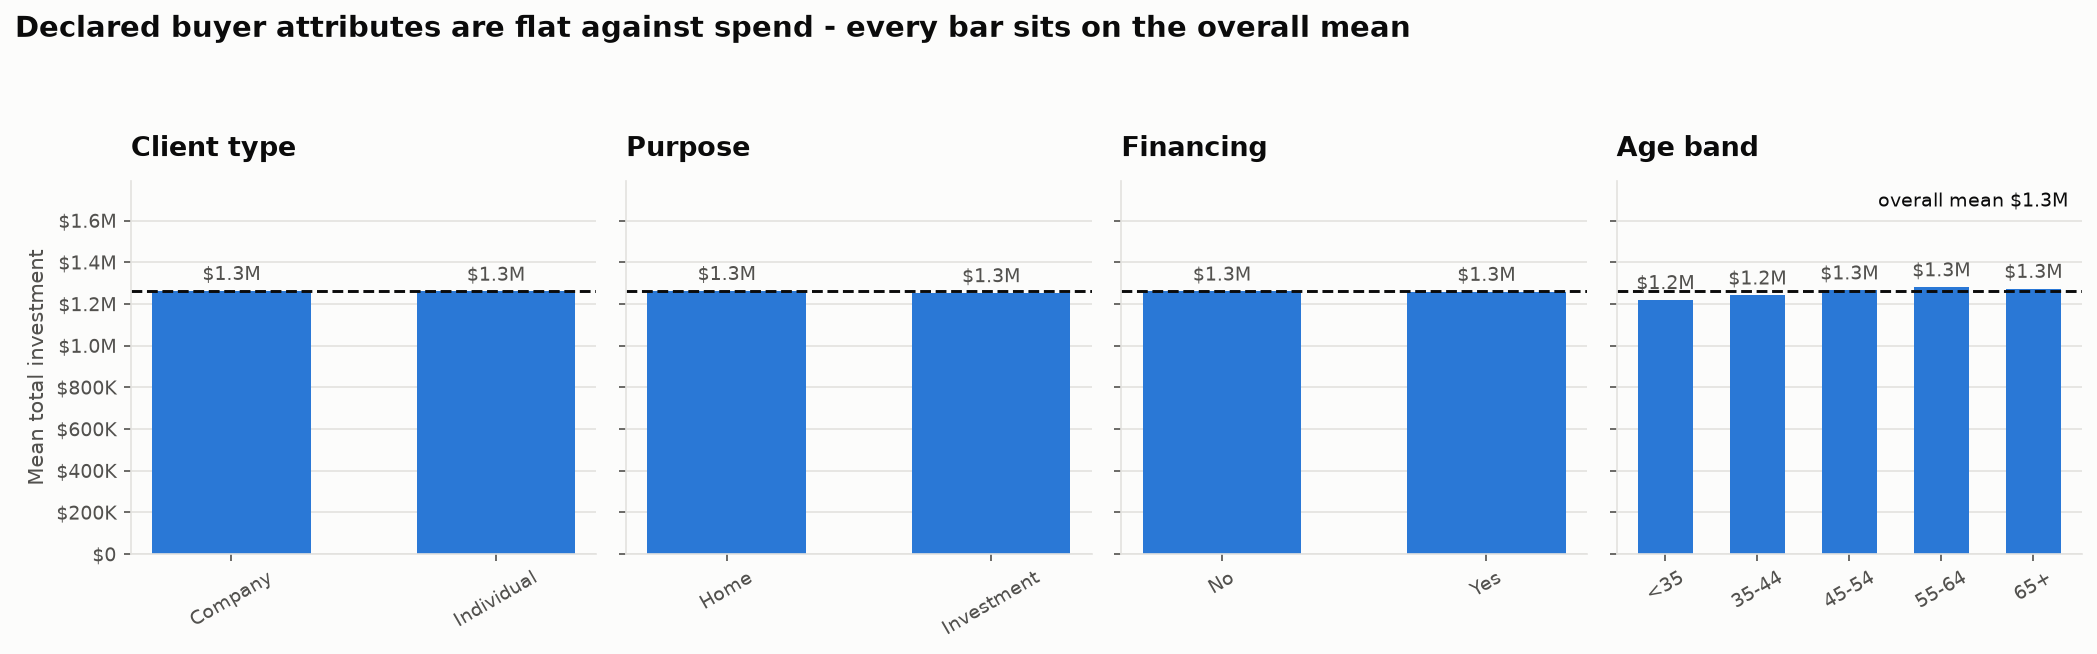

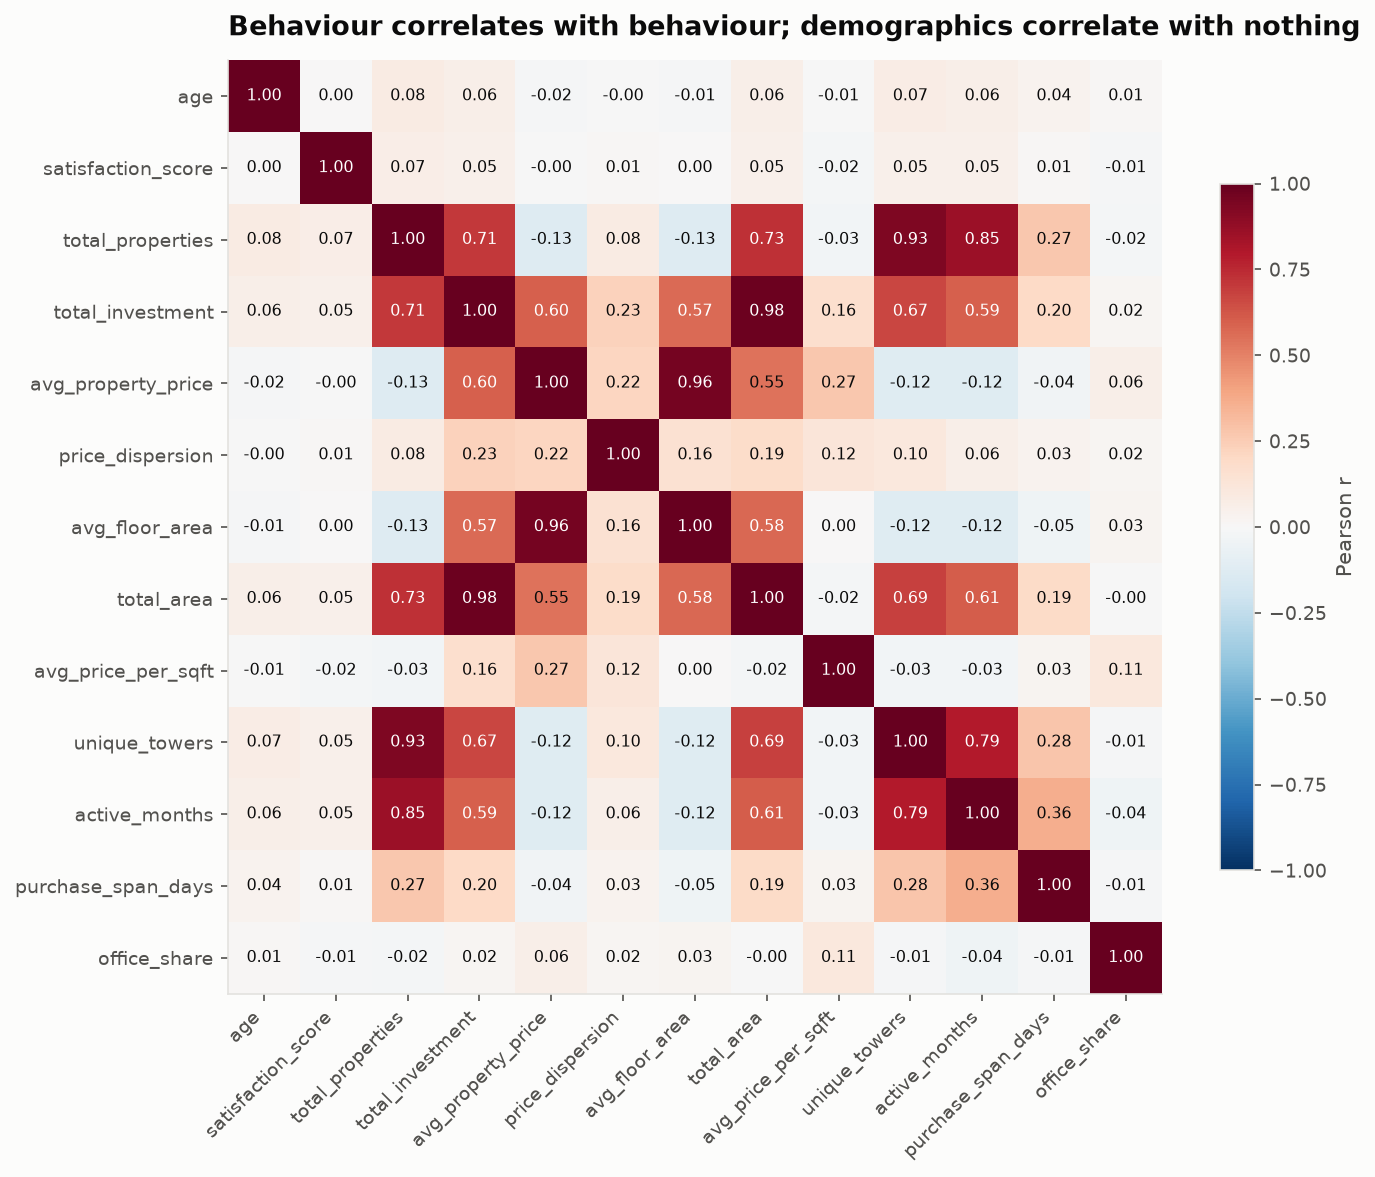

In [6]:
display(Image(str(vz.fig_intent_vs_investment(features))))
CORR = ['age','satisfaction_score','total_properties','total_investment',
        'avg_property_price','price_dispersion','avg_floor_area','total_area',
        'avg_price_per_sqft','unique_towers','active_months',
        'purchase_span_days','office_share']
display(Image(str(vz.fig_correlation_heatmap(features, CORR))))
